In [1]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import mahotas as mt

In [2]:
ds_path = "D:/skripsi/pisang"


In [3]:
test_img_path = ds_path +"\\cord_ (4).JPEG"
test_img_path

'D:/skripsi/pisang\\cord_ (4).JPEG'

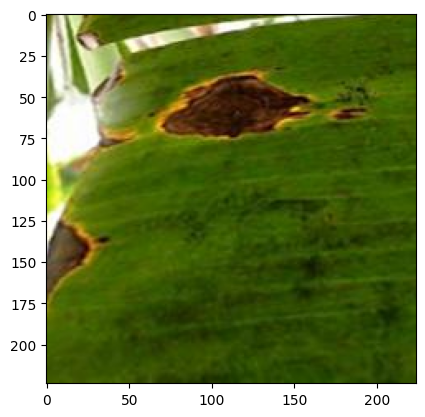

In [4]:
main_img = cv2.imread(test_img_path)
# Cek apakah gambar berhasil dibaca
if main_img is not None:
    img = cv2.cvtColor(main_img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
else:
    print("Gambar tidak dapat dibaca!")

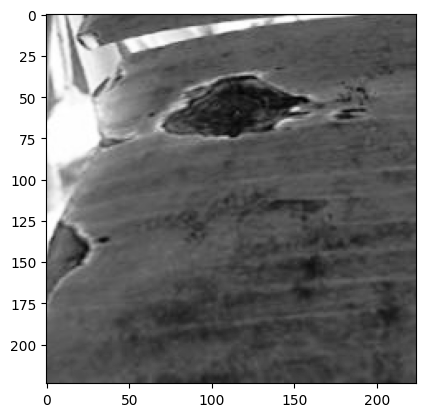

In [5]:
gs = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
plt.imshow(gs,cmap='Greys_r')

In [6]:
gs.shape

(224, 224)

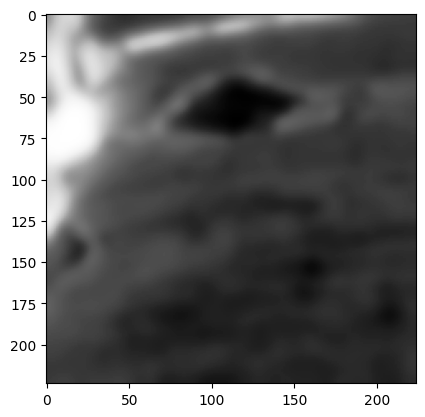

In [7]:
blur = cv2.GaussianBlur(gs, (25,25), 0)
plt.imshow(blur, cmap = 'Greys_r')

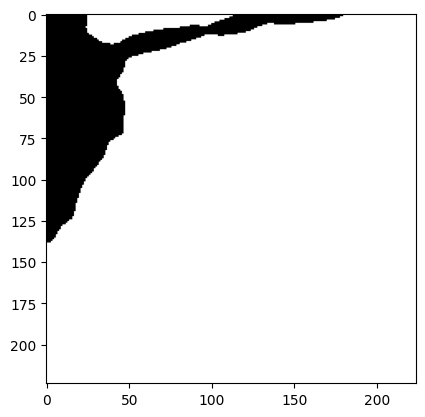

In [8]:
ret_otsu, im_bw_otsu = cv2.threshold(blur, 0 ,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
plt.imshow(im_bw_otsu,cmap='Greys_r')

In [9]:
kernel = np.ones((50,50),np.uint8)
closing = cv2.morphologyEx(im_bw_otsu, cv2.MORPH_CLOSE, kernel)

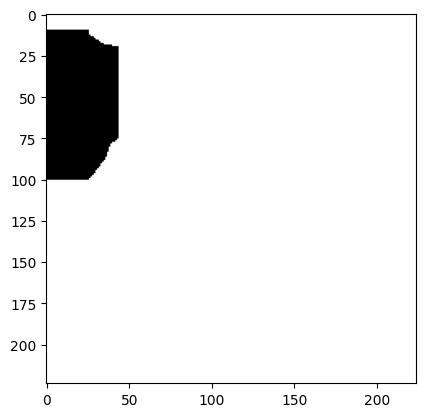

In [10]:
plt.imshow(closing,cmap='Greys_r')

In [11]:
#1. Color based features

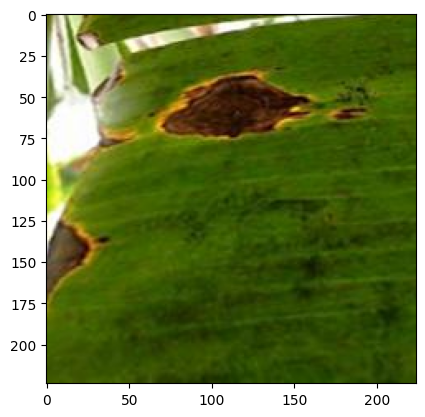

In [12]:
plt.imshow(img,cmap="Greys_r")

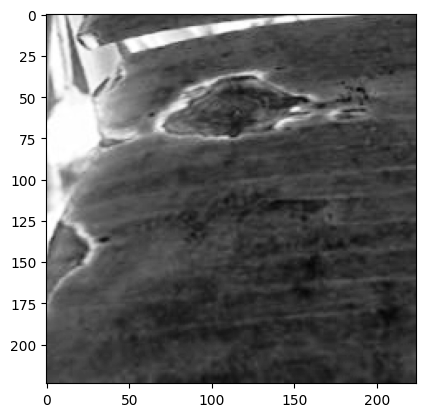

In [13]:
red_channel = img[:,:,0]
plt.imshow(red_channel,cmap="Greys_r")

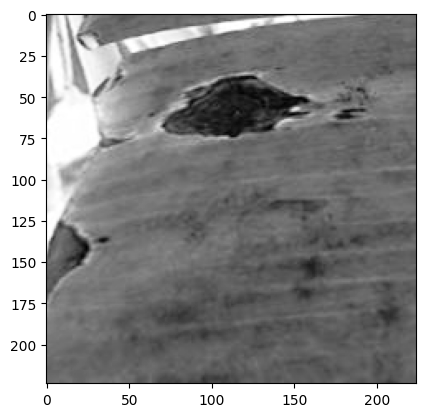

In [14]:
green_channel = img[:,:,1]
plt.imshow(green_channel,cmap="Greys_r")

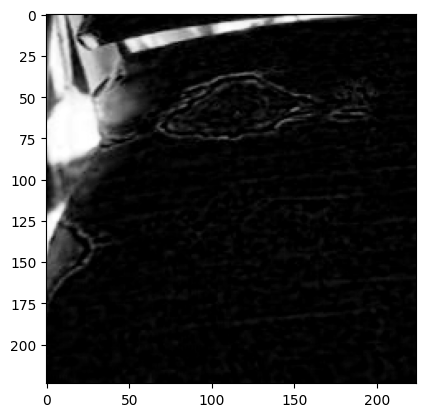

In [15]:
blue_channel = img[:,:,2]
plt.imshow(blue_channel,cmap="Greys_r")

In [16]:
np.mean(blue_channel)

21.117107780612244

In [17]:
blue_channel[blue_channel == 255] = 0
green_channel[green_channel == 255] = 0
red_channel[red_channel == 255] = 0


In [18]:
red_mean = np.mean(red_channel)
red_mean

75.06742267219387

In [19]:
green_mean = np.mean(green_channel)
green_mean

94.50573979591837

In [20]:
blue_mean = np.mean(blue_channel)
blue_mean

19.993961256377553

In [21]:
red_var = np.std(red_channel)
red_var

47.55818194824961

In [22]:
red_mean = np.mean(red_channel)
green_mean = np.mean(green_channel)
blue_mean = np.mean(blue_channel)
red_std = np.std(red_channel)
green_std = np.std(green_channel)
blue_std = np.std(blue_channel)

In [23]:
#3. Texture based features
#Using Haralick moments - calculating texture based features such as contrast, correlation, entropy

In [24]:
textures = mt.features.haralick(gs)
ht_mean = textures.mean(axis=0)
ht_mean

array([ 1.27804030e-03,  1.41659376e+02,  9.64677748e-01,  2.00583901e+03,
        2.64591175e-01,  1.63886123e+02,  7.88169668e+03,  7.55369620e+00,
        1.09089409e+01,  4.16983818e-04,  3.84084207e+00, -3.39820896e-01,
        9.93213389e-01])

In [25]:
print(ht_mean[1]) #contrast
print(ht_mean[2]) #correlation
print(ht_mean[4]) #inverse difference moments
print(ht_mean[8]) #entropy

141.659375511702
0.9646777482393984
0.26459117543823496
10.90894085343235


In [26]:
import pandas as pd

def extract_features(test_img_path):

    # Create DataFrame
    features = {
        'mean_r': [red_mean],
        'mean_g': [green_mean],
        'mean_b': [blue_mean],
        'stddev_r': [red_std],
        'stddev_g': [green_std],
        'stddev_b': [blue_std],
        'contrast': [ht_mean[1]],
        'correlation': [ht_mean[2]],
        'inverse_difference_moments': [ht_mean[4]],
        'entropy': [ht_mean[8]]
    }
    df = pd.DataFrame(features)
    return df

# Execute and display the results
try:
    test_img_path = "D:/skripsi/pisang/cord_ (4).JPEG"  # Replace with your actual image path
    features_df = extract_features(test_img_path)
    print("Fitur yang diekstraksi dari gambar:")
    print(features_df)
except Exception as e:
    print(f"Error: {e}")

Fitur yang diekstraksi dari gambar:
      mean_r    mean_g     mean_b   stddev_r   stddev_g   stddev_b  \
0  75.067423  94.50574  19.993961  47.558182  41.826767  48.839107   

     contrast  correlation  inverse_difference_moments    entropy  
0  141.659376     0.964678                    0.264591  10.908941  
